# Boston Housing Analysis

**Supervised Learning: Regression & Classification**

In [33]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
   mean_squared_error, r2_score,
   accuracy_score, precision_score, recall_score, f1_score,
   confusion_matrix, ConfusionMatrixDisplay
)

In [34]:
#Load Dataset
df = pd.read_csv("HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [35]:
#Explore Dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0.554695   

In [36]:
#Clean Data
df.dropna(inplace=True)

**Linear Regression**

In [37]:
#Predicting MEDV

In [38]:
#Define features and target
X_reg = df.drop("MEDV", axis = 1)
y_reg = df['MEDV']

In [39]:
#Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [40]:
#Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

#predict
y_pred_reg = lr_model.predict(X_test_reg)

In [41]:
#Evalute
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

#print regression 
print("Linear Regression")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Linear Regression
RMSE: 5.61
R2 Score: 0.63


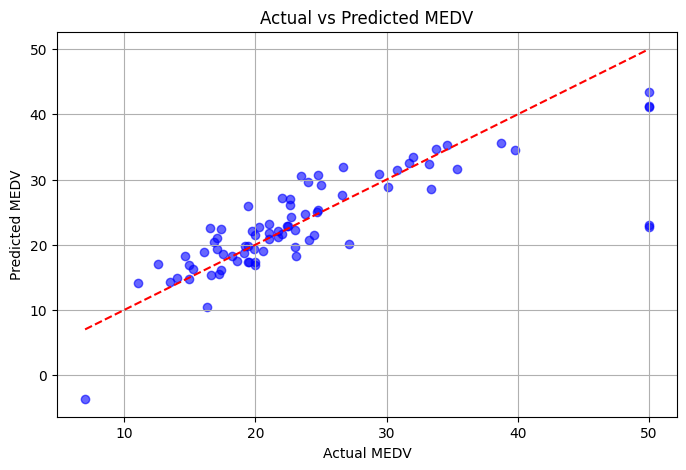

In [42]:
#Plot Actual vs Predicted prices
plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_reg, color='blue', alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted MEDV")
plt.grid(True)
plt.show()


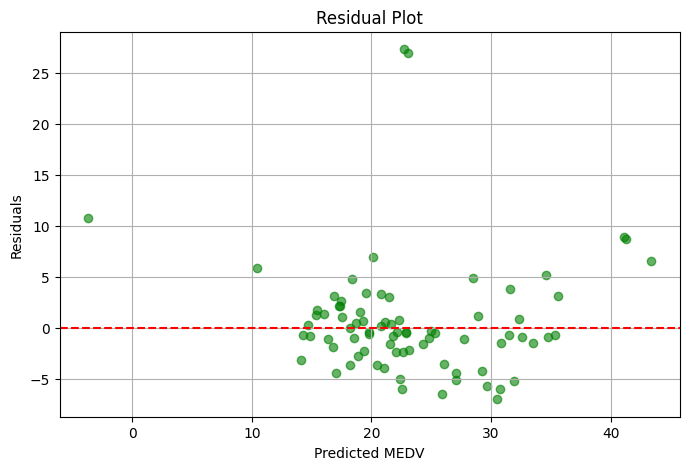

In [43]:
#plot residuals (prediction errors)
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8,5))
plt.scatter(y_pred_reg, residuals, color='green', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

**Logistic Regression**

In [44]:
#Create binary target: 1 if MEDV >= median, else 0
median_val = df['MEDV'].median()
df["HighPrice"] = (df["MEDV"] >= median_val).astype(int)

In [45]:
#Define features and target for classification
X_clf = df.drop(["MEDV", "HighPrice"], axis=1)
y_clf = df["HighPrice"]


In [46]:
#Split into train and test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


In [47]:
#Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_clf, y_train_clf)

C:\Users\Prajaktakale\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [48]:
#Predict and evaluate
y_pred_clf = log_model.predict(X_test_clf)
acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print("\nLogistic Regression (Classification)")
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score {f1:.2f}")


Logistic Regression (Classification)
Accuracy: 0.82
Precision: 0.83
Recall: 0.83
F1 Score 0.83


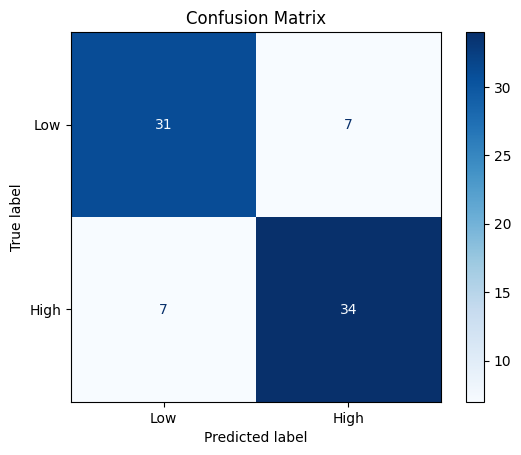

In [49]:
#Plot confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low","High"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()